Example - Quantum dot driven by a laser pulse

In [1]:
import oqupy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sigma_x = oqupy.operators.sigma("x")
sigma_y = oqupy.operators.sigma("y")
sigma_z = oqupy.operators.sigma("z")
up_density_matrix = oqupy.operators.spin_dm("z+")
down_density_matrix = oqupy.operators.spin_dm("z-")
mixed_density_matrix = oqupy.operators.spin_dm("mixed")

In [3]:
omega_cutoff = 3.04
alpha = 0.126
temperature = 0.1309
initial_state=down_density_matrix

In [4]:
def gaussian_shape(t, area = 1.0, tau = 1.0, t_0 = 0.0):
    return area/(tau*np.sqrt(np.pi)) * np.exp(-(t-t_0)**2/(tau**2))

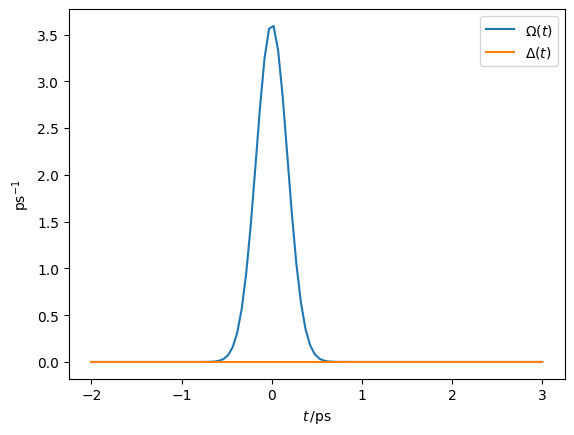

In [5]:
detuning = lambda t: 0.0 * t

t = np.linspace(-2,3,100)
Omega_t = gaussian_shape(t, area = np.pi/2.0, tau = 0.245)
Delta_t = detuning(t)

plt.plot(t, Omega_t,label=r"$\Omega(t)$")
plt.plot(t, Delta_t,label=r"$\Delta(t)$")
plt.xlabel(r"$t\,/\mathrm{ps}$")
plt.ylabel(r"$\mathrm{ps}^{-1}$")
plt.legend()

In [6]:
def hamiltonian_t(t):
    return detuning(t)/2.0 * sigma_z \
           + gaussian_shape(t, area = np.pi/2.0, tau = 0.245)/2.0 * sigma_x

system = oqupy.TimeDependentSystem(hamiltonian_t)
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=3,
                                cutoff=omega_cutoff,
                                cutoff_type='gaussian',
                                temperature=temperature)
bath = oqupy.Bath(sigma_z/2.0, correlations)

In [13]:
tempo_parameters = oqupy.TempoParameters(dt=0.1, tcut=2.0, epsrel=10**(-4))

tempo_sys = oqupy.Tempo(system=system,
                        bath=bath,
                        initial_state=initial_state,
                        start_time=-2.0,
                        parameters=tempo_parameters)
dynamics = tempo_sys.compute(end_time=3.0)

--> TEMPO computation:
  0.0%    0 of   50 [----------------------------------------] 00:00:10

1608.39s - thread._ident is None in _get_related_thread!


  0.0%    0 of   50 [----------------------------------------] 00:01:08

58.14s - thread._ident is None in _get_related_thread!


  0.0%    0 of   50 [----------------------------------------] 00:01:27

18.69s - thread._ident is None in _get_related_thread!


  2.0%    1 of   50 [----------------------------------------] 00:01:31

5.32s - thread._ident is None in _get_related_thread!


100.0%   50 of   50 [########################################] 00:01:36
Elapsed time: 96.7s


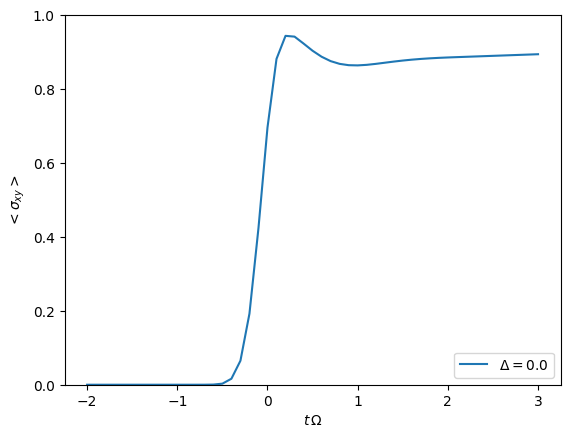

In [8]:
t, s_x = dynamics.expectations(sigma_x, real=True)
t, s_y = dynamics.expectations(sigma_y, real=True)
s_xy = np.sqrt(s_x**2 + s_y**2)
plt.plot(t, s_xy, label=r'$\Delta = 0.0$')
plt.xlabel(r'$t\,\Omega$')
plt.ylabel(r'$<\sigma_{xy}>$')
plt.ylim((0.0,1.0))
plt.legend(loc=4)

In [14]:
tempo_parameters = oqupy.TempoParameters(dt=0.1, tcut=2.0, epsrel=10**(-4))

process_tensor = oqupy.pt_tempo_compute(bath=bath,
                                        start_time=-2.0,
                                        end_time=3.0,
                                        parameters=tempo_parameters)

--> PT-TEMPO computation:
100.0%   50 of   50 [########################################] 00:00:22
Elapsed time: 22.7s


In [10]:
deltas = [-10.0, -5.0, 0.0, 5.0, 10.0]
systems = []
for delta in deltas:
    # NOTE: omitting "delta=delta" in the parameter definition below
    #       would lead to all systems having the same detuning.
    #       This is a common python pitfall. Check out
    #       https://docs.python-guide.org/writing/gotchas/#late-binding-closures
    #       for more information on this.
    def hamiltonian_t(t, delta=delta):
        return delta/2.0 * sigma_z \
            + gaussian_shape(t, area = np.pi/2.0, tau = 0.245)/2.0 * sigma_x
    system = oqupy.TimeDependentSystem(hamiltonian_t)
    systems.append(system)

In [11]:
s_xy_list = []
t_list = []
for system in systems:
    dynamics = oqupy.compute_dynamics(
        process_tensor=process_tensor,
        system=system,
        initial_state=initial_state,
        start_time=-2.0,
        progress_type="silent")
    t, s_x = dynamics.expectations(sigma_x, real=True)
    _, s_y = dynamics.expectations(sigma_y, real=True)
    s_xy = np.sqrt(s_x**2 + s_y**2)
    s_xy_list.append(s_xy)
    t_list.append(t)
    print(".", end="", flush=True)
print(" done.", flush=True)

..... done.


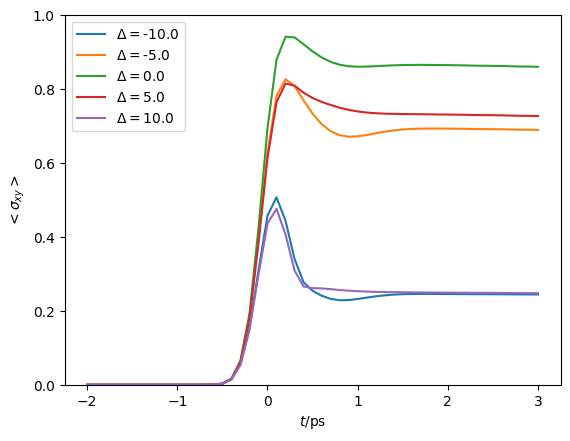

In [12]:
for t, s_xy, delta in zip(t_list, s_xy_list, deltas):
    plt.plot(t, s_xy, label=r"$\Delta = $"+f"{delta:0.1f}")
    plt.xlabel(r'$t/$ps')
    plt.ylabel(r'$<\sigma_{xy}>$')
plt.ylim((0.0,1.0))
plt.legend()